In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path

In [5]:
BASE = Path("/home/akoua/.cache/kagglehub/datasets/pratt3000/nisqa-corpus/versions/1/NISQA_Corpus")

# Confirm structure
for item in sorted(os.listdir(BASE)):
    print(item)

NISQA_TEST_FOR
NISQA_TEST_LIVETALK
NISQA_TEST_P501
NISQA_TRAIN_LIVE
NISQA_TRAIN_SIM
NISQA_VAL_LIVE
NISQA_VAL_SIM
NISQA_corpus_con.csv
NISQA_corpus_file.csv
readme.txt


In [6]:
df_file = pd.read_csv(BASE / "NISQA_corpus_file.csv")
df_con  = pd.read_csv(BASE / "NISQA_corpus_con.csv")

print("File-level shape:", df_file.shape)
print("Condition-level shape:", df_con.shape)
print("\nColumns:", df_file.columns.tolist())
df_file.head()

File-level shape: (14432, 21)
Condition-level shape: (13898, 20)

Columns: ['db', 'con', 'file', 'con_description', 'filename_deg', 'filename_ref', 'source', 'lang', 'votes', 'mos', 'noi', 'col', 'dis', 'loud', 'noi_std', 'col_std', 'dis_std', 'loud_std', 'mos_std', 'filepath_deg', 'filepath_ref']


,db,con,file,con_description,filename_deg,filename_ref,source,lang,votes,mos,...,col,dis,loud,noi_std,col_std,dis_std,loud_std,mos_std,filepath_deg,filepath_ref
0,NISQA_TEST_FOR,1.0,1.0,Anchor: Fullband clean,c00001_for_cnv_m_0103_01.wav,for_cnv_m_0103_01.wav,FOR,en,26.0,4.346154,...,4.189403,4.405050,4.397604,0.713027,0.784720,0.616300,0.647064,0.797110,NISQA_TEST_FOR/deg/c00001_for_cnv_m_0103_01.wav,NISQA_TEST_FOR/ref/for_cnv_m_0103_01.wav
1,NISQA_TEST_FOR,1.0,2.0,Anchor: Fullband clean,c00001_for_cnv_m_1035_02.wav,for_cnv_m_1035_02.wav,FOR,en,31.0,4.516129,...,4.290818,4.146045,4.359024,0.563135,0.651041,0.842191,0.670296,0.569852,NISQA_TEST_FOR/deg/c00001_for_cnv_m_1035_02.wav,NISQA_TEST_FOR/ref/for_cnv_m_1035_02.wav
2,NISQA_TEST_FOR,1.0,3.0,Anchor: Fullband clean,c00001_for_cnv_f_0104_02.wav,for_cnv_f_0104_02.wav,FOR,en,28.0,4.321429,...,4.252780,3.968875,4.333607,0.683793,0.935352,1.199506,0.915960,0.772374,NISQA_TEST_FOR/deg/c00001_for_cnv_f_0104_02.wav,NISQA_TEST_FOR/ref/for_cnv_f_0104_02.wav
3,NISQA_TEST_FOR,1.0,4.0,Anchor: Fullband clean,c00001_for_cnv_f_0113_03.wav,for_cnv_f_0113_03.wav,FOR,en,32.0,4.531250,...,4.132725,4.315563,4.254879,0.701800,0.758961,0.682773,0.707230,0.567074,NISQA_TEST_FOR/deg/c00001_for_cnv_f_0113_03.wav,NISQA_TEST_FOR/ref/for_cnv_f_0113_03.wav
4,NISQA_TEST_FOR,2.0,5.0,Anchor: P50MNRU 25dB,c00002_for_cnv_m_0068_01.wav,for_cnv_m_0068_01.wav,FOR,en,23.0,3.739130,...,3.206392,4.044426,3.881243,1.125980,1.331290,0.960276,1.086562,0.915393,NISQA_TEST_FOR/deg/c00002_for_cnv_m_0068_01.wav,NISQA_TEST_FOR/ref/for_cnv_m_0068_01.wav


In [7]:
train_live = df_file[df_file["db"].str.contains("TRAIN_LIVE", na=False)].copy()

print(f"TRAIN_LIVE files: {len(train_live)}")
print(f"Unique speakers:  {train_live['speaker_id'].nunique() if 'speaker_id' in train_live.columns else 'col name TBD'}")
print(f"\nMissing values:\n{train_live.isnull().sum()}")
train_live.head()

TRAIN_LIVE files: 1020
Unique speakers:  col name TBD

Missing values:
db                 0
con                0
file               0
con_description    0
filename_deg       0
filename_ref       0
source             0
lang               0
votes              0
mos                0
noi                0
col                0
dis                0
loud               0
noi_std            0
col_std            0
dis_std            0
loud_std           0
mos_std            0
filepath_deg       0
filepath_ref       0
dtype: int64


,db,con,file,con_description,filename_deg,filename_ref,source,lang,votes,mos,...,col,dis,loud,noi_std,col_std,dis_std,loud_std,mos_std,filepath_deg,filepath_ref
712,NISQA_TRAIN_LIVE,1.0,1.0,VoIP-landline to mobile,book_00000_chp_0009_reader_06709_17_seg_live_p...,book_00000_chp_0009_reader_06709_17_seg.wav,DNS,en,4.0,2.75,...,1.971515,2.655383,2.630288,0.600157,0.344357,1.276994,0.992185,0.500000,NISQA_TRAIN_LIVE/deg/book_00000_chp_0009_reade...,NISQA_TRAIN_LIVE/ref/book_00000_chp_0009_reade...
713,NISQA_TRAIN_LIVE,2.0,2.0,VoIP-landline to mobile,book_00000_chp_0009_reader_06709_17_seg_live_p...,book_00000_chp_0009_reader_06709_17_seg.wav,DNS,en,5.0,2.80,...,2.354388,4.021275,2.766868,1.126987,1.226691,0.720210,1.223601,0.836660,NISQA_TRAIN_LIVE/deg/book_00000_chp_0009_reade...,NISQA_TRAIN_LIVE/ref/book_00000_chp_0009_reade...
714,NISQA_TRAIN_LIVE,3.0,3.0,Skype,book_00000_chp_0009_reader_06709_17_seg_live_s...,book_00000_chp_0009_reader_06709_17_seg.wav,DNS,en,5.0,3.20,...,2.885656,4.109504,2.393545,0.821261,0.804900,0.409096,0.660927,0.447214,NISQA_TRAIN_LIVE/deg/book_00000_chp_0009_reade...,NISQA_TRAIN_LIVE/ref/book_00000_chp_0009_reade...
715,NISQA_TRAIN_LIVE,4.0,4.0,Skype,book_00000_chp_0009_reader_06709_17_seg_live_s...,book_00000_chp_0009_reader_06709_17_seg.wav,DNS,en,5.0,3.40,...,2.589196,4.347896,3.309449,0.749696,1.053020,0.861649,1.069251,0.547723,NISQA_TRAIN_LIVE/deg/book_00000_chp_0009_reade...,NISQA_TRAIN_LIVE/ref/book_00000_chp_0009_reade...
716,NISQA_TRAIN_LIVE,5.0,5.0,VoIP-landline to mobile,book_00007_chp_0008_reader_01326_58_seg_live_p...,book_00007_chp_0008_reader_01326_58_seg.wav,DNS,en,5.0,1.80,...,1.663828,3.397215,1.916155,0.970530,0.677514,1.314756,0.769558,0.836660,NISQA_TRAIN_LIVE/deg/book_00007_chp_0008_reade...,NISQA_TRAIN_LIVE/ref/book_00007_chp_0008_reade...


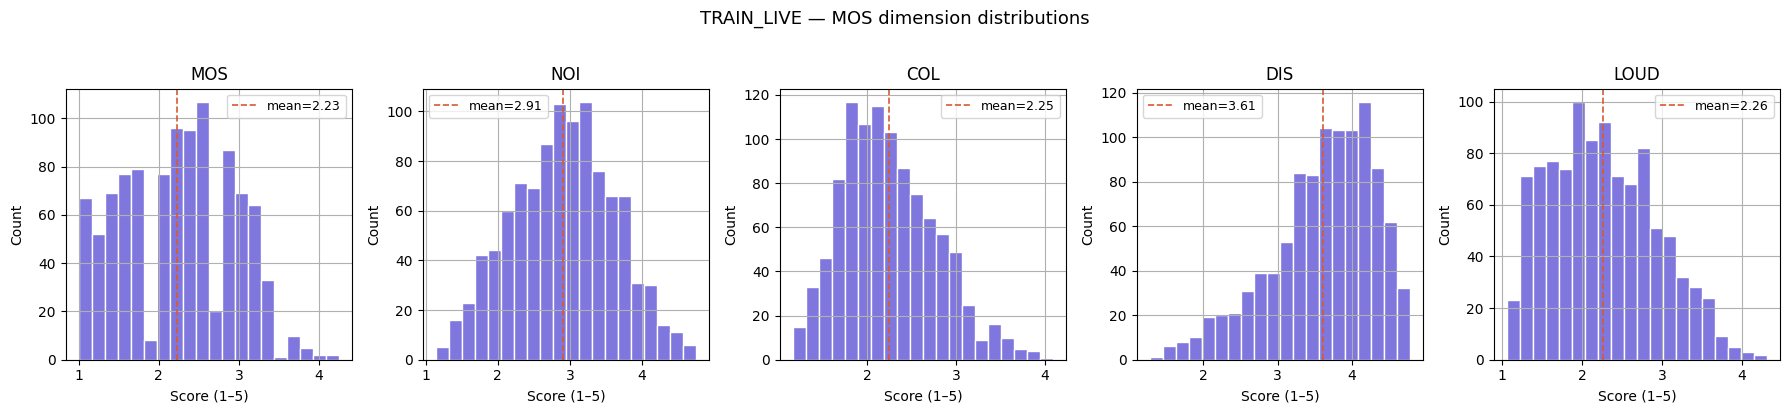

            mos       noi       col       dis      loud
count  1020.000  1020.000  1020.000  1020.000  1020.000
mean      2.229     2.907     2.247     3.609     2.260
std       0.699     0.713     0.531     0.691     0.665
min       1.000     1.139     1.157     1.286     1.057
25%       1.600     2.385     1.855     3.214     1.740
50%       2.200     2.918     2.174     3.715     2.199
75%       2.800     3.399     2.598     4.137     2.756
max       4.250     4.747     4.093     4.776     4.314


In [8]:
dims = ["mos", "noi", "col", "dis", "loud"]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, dim in zip(axes, dims):
    train_live[dim].hist(bins=20, ax=ax, color="#7F77DD", edgecolor="white")
    ax.set_title(dim.upper(), fontsize=12)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("Count")
    ax.axvline(train_live[dim].mean(), color="#D85A30", linestyle="--", linewidth=1.2, label=f"mean={train_live[dim].mean():.2f}")
    ax.legend(fontsize=9)

plt.suptitle("TRAIN_LIVE — MOS dimension distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(train_live[dims].describe().round(3))

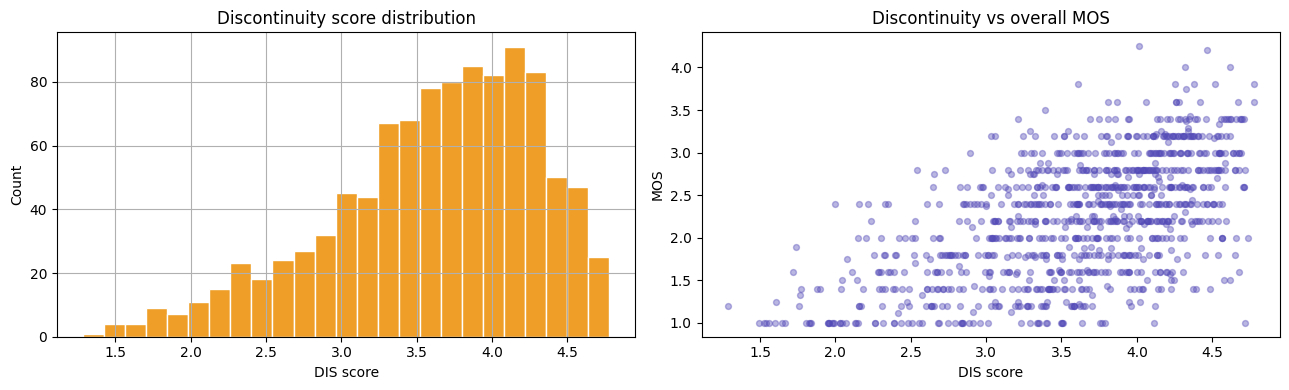

dis_bucket
severe     28
poor      155
fair      493
good      344
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
train_live["dis"].hist(bins=25, ax=axes[0], color="#EF9F27", edgecolor="white")
axes[0].set_title("Discontinuity score distribution")
axes[0].set_xlabel("DIS score")
axes[0].set_ylabel("Count")

# DIS vs overall MOS
axes[1].scatter(train_live["dis"], train_live["mos"], alpha=0.4, color="#534AB7", s=18)
axes[1].set_title("Discontinuity vs overall MOS")
axes[1].set_xlabel("DIS score")
axes[1].set_ylabel("MOS")

plt.tight_layout()
plt.show()

# Stratify into severity buckets
train_live["dis_bucket"] = pd.cut(train_live["dis"], bins=[1, 2, 3, 4, 5], labels=["severe", "poor", "fair", "good"])
print(train_live["dis_bucket"].value_counts().sort_index())

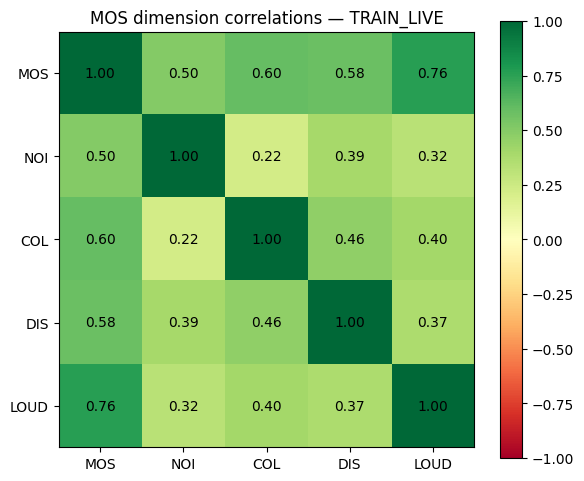

In [10]:
import matplotlib.colors as mcolors

corr = train_live[dims].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(dims)))
ax.set_yticks(range(len(dims)))
ax.set_xticklabels([d.upper() for d in dims])
ax.set_yticklabels([d.upper() for d in dims])

for i in range(len(dims)):
    for j in range(len(dims)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)

ax.set_title("MOS dimension correlations — TRAIN_LIVE")
plt.tight_layout()
plt.show()

In [15]:
durations = []
sample_rates = []
failed = []

audio_dir = BASE / "NISQA_TRAIN_LIVE" / "deg"

# Files on disk
files_on_disk = set(os.listdir(audio_dir))

# Files referenced in CSV
files_in_csv = set(train_live["filename_deg"].values)

print(f"Files on disk:     {len(files_on_disk)}")
print(f"Files in CSV:      {len(files_in_csv)}")
print(f"Matched:           {len(files_on_disk & files_in_csv)}")
print(f"In CSV not on disk: {len(files_in_csv - files_on_disk)}")
print(f"\nSample filenames on disk: {list(files_on_disk)[:3]}")
print(f"Sample filenames in CSV:  {list(files_in_csv)[:3]}")

Files on disk:     1020
Files in CSV:      1020
Matched:           1020
In CSV not on disk: 0

Sample filenames on disk: ['book_10082_chp_0030_reader_00447_1_seg_live_phone_548.wav', 'book_10076_chp_0017_reader_08346_7_seg_live_skype_547.wav', 'book_08757_chp_0011_reader_00212_4_seg_live_phone_482.wav']
Sample filenames in CSV:  ['book_10082_chp_0030_reader_00447_1_seg_live_phone_548.wav', 'book_10076_chp_0017_reader_08346_7_seg_live_skype_547.wav', 'book_08757_chp_0011_reader_00212_4_seg_live_phone_482.wav']
